## 1) Loading in data

The idea is that we have a configuration file for each dataset that will tell us how to load in the data for that particular dataset. Data has multiple relations with eachother:

- each sequence has some associated records, e.g. DMS scores, engineering round, which kfold should it be in?
- these associated records come from a particular assay
- assay conditions might be different between different assays, this is usefull meta data that could be incorporated into model building
- besides the assay meta data, there might be meta data on the full dataset, e.g. the author, publication DOI. Tracking all this information is foundational to FAIR data

This should also suit the extra list of columns Elain is working on. Some of the columns can be added to assay data, some to meta data and some as columns to the records CSV.




### 1.1) The dataset.toml file is the configuration file for the dataset

Our proposal to this is using the dataset.toml file which contains all the required information to go from the data on your disk to a pythonic object.


The current toml file looks as follows:

<div class="alert alert-block alert-info">
[artifacts] <br>
records = "pg2-dataset/example_data/v2/A0A1I9GEU1_NEIME_Kennouche_2019/substitutions_rounds.csv" <br>
structure = "pg2-dataset/example_data/v1/A0A1I9GEU1_NEIME_Kennouche_2019/structure.cif" <br>
msa = "data/msa.npy" <br>
</div>


The [artifacts] section describes where the files are positioned on the disk. The current setup also allows us to point to URIs.
So e.g., we can host a git repository with the files, and point the toml to this git location. This way we can track datasets and always load them as long as we have an internet connection.

**Unimplemented feature**: Host the [artifacts] as a zip file which contains the toml file plus artifacts. That way you can share a single file that is fully self contained for making the pg2-dataset object.

<div class="alert alert-block alert-info">
[records] <br>
sequence_feature = "mutated_sequence" <br> 
columns = ["mutated_sequence", "mutant", "DMS_score", "DMS_score_bin", "engineering_round"] <br>
schemas = ["pl.String", "pl.String", "pl.Float32", "pl.Float32"] <br>
</div>


In the [records] section we mark which column contains the sequence, for mapping the correct information
Columns allow us to mark which columns from e.g. a CSV file should be in our dataset. Schemas is a temporary string for type checking that we get the data we expect to get. 

<div class="alert alert-block alert-info">
[metadata] <br>
name = "project name" <br>
description = "project description" <br>
doi = "DOI: 10.1000/xyz123" <br>
source = "DOI: 10.1000/xyz123" <br>
xref = "" <br>
<br>
[[assays]] <br>
name = "assay one" <br>
description = "assays one description" <br>
<br>
[assays.columns] <br>
features = ["feature1", "feature2"] <br>
target = "target1" <br>
<br> 
[assays.constants] <br>
key1 = "recorded on a X device" <br>
key2 = "37 Celsius" <br>
</div>


### 1.2) Flexibility in loading and using data

We can load in the dataset as sequences (Records), structures and MSAs.

To load in a dataset we import our dataset and point it to the toml file:

In [1]:
from pg2_dataset.backends.records import RecordsDataset
from pg2_dataset.backends.structure import StructureDataset
from pg2_dataset.backends.combined import CombinedDataset
# (MSA needs to be added here too)

dataset = CombinedDataset(  # can also be a RecordDataset or StructureDataset
    toml_file="../example_data/A0A1I9GEU1_NEIME_Kennouche_2019.toml",
    include_records=True,
    include_structure=True,
)

The dataset contains all the combined information in a python object:

In [2]:
dataset

CombinedDataset(toml_file='../example_data/A0A1I9GEU1_NEIME_Kennouche_2019.toml', include_records=True, include_structure=True, include_msa=False, splits={}, structure_file_path='/Users/vanderweg/Projects/PG2/pg2-dataset/example_data/v1/A0A1I9GEU1_NEIME_Kennouche_2019/structure.cif', records_file_path='/Users/vanderweg/Projects/PG2/pg2-dataset/example_data/v2/A0A1I9GEU1_NEIME_Kennouche_2019/substitutions_rounds.csv', sequence_feature='mutated_sequence', engineering_round_feature=None, columns=['sequence', 'mutant', 'DMS_score', 'DMS_score_bin', 'engineering_round'], schemas=[String, String, Float32, Float32], settings=DatasetSettings(artifacts=Artifacts(records='/Users/vanderweg/Projects/PG2/pg2-dataset/example_data/v2/A0A1I9GEU1_NEIME_Kennouche_2019/substitutions_rounds.csv', structure='/Users/vanderweg/Projects/PG2/pg2-dataset/example_data/v1/A0A1I9GEU1_NEIME_Kennouche_2019/structure.cif', msa=None), records=Records(sequence_feature='mutated_sequence', engineering_round_feature=None,

We can attach helpfull methods and properties to the dataset:

In [3]:
dataset.data_frame()

,sequence,mutant,DMS_score,DMS_score_bin,engineering_round
0,ITLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,F1I,-3.598,0.0,3
1,LTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,F1L,-0.678,0.0,1
2,YTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,F1Y,-2.373,0.0,3
3,VTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,F1V,1.299,1.0,3
4,STLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,F1S,-0.127,0.0,1
...,...,...,...,...,...
917,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,S161R,-0.344,0.0,3
918,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,S161I,1.472,1.0,3
919,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,S161G,0.345,1.0,1
920,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,S161T,-1.969,0.0,3


Or access specific parts of the data, e.g. record information:

In [4]:
dataset.records[0:5]

[Record(engineering_round=3, sequence='ITLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSAVTEYYLNHGEWPGDNSSAGVATSADIKGKYVQSVTVANGVITAQMASSNVNNEIKSKKLSLWAKRQNGSVKWFCGQPVTRTTATATDVAAANGKTDDKINTKHLPSTCRDDSSAS', mutant='F1I', DMS_score=-3.5980000495910645, DMS_score_bin=0.0),
 Record(engineering_round=1, sequence='LTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSAVTEYYLNHGEWPGDNSSAGVATSADIKGKYVQSVTVANGVITAQMASSNVNNEIKSKKLSLWAKRQNGSVKWFCGQPVTRTTATATDVAAANGKTDDKINTKHLPSTCRDDSSAS', mutant='F1L', DMS_score=-0.6779999732971191, DMS_score_bin=0.0),
 Record(engineering_round=3, sequence='YTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSAVTEYYLNHGEWPGDNSSAGVATSADIKGKYVQSVTVANGVITAQMASSNVNNEIKSKKLSLWAKRQNGSVKWFCGQPVTRTTATATDVAAANGKTDDKINTKHLPSTCRDDSSAS', mutant='F1Y', DMS_score=-2.372999906539917, DMS_score_bin=0.0),
 Record(engineering_round=3, sequence='VTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSAVTEYYLNHGEWPGDNSSAGVATSADIKGKYVQSVTVANGVITAQMASSNVNNEIKSKKLSLWAKRQNGSVKWFCGQPVTRTTATATDVAAANGKTDDKINTKHLPSTCRDDS

or e.g. structure information: (Current implementation only supports MMCif files yet)

In [5]:
dataset.structure

MMcifFile(key_value_pairs=[MMcifEntry(key='_entry.id', value='AF-A0A1I9GEU1-F1'), MMcifEntry(key='_audit_conform.dict_location', value='https://raw.githubusercontent.com/ihmwg/ModelCIF/master/dist/mmcif_ma.dic'), MMcifEntry(key='_audit_conform.dict_name', value='mmcif_ma.dic'), MMcifEntry(key='_audit_conform.dict_version', value='1.3.9'), MMcifEntry(key='_citation.book_publisher', value='?'), MMcifEntry(key='_citation.country', value='UK'), MMcifEntry(key='_citation.id', value='primary'), MMcifEntry(key='_citation.journal_full', value='Nature'), MMcifEntry(key='_citation.journal_id_ASTM', value='NATUAS'), MMcifEntry(key='_citation.journal_id_CSD', value='0006'), MMcifEntry(key='_citation.journal_id_ISSN', value='0028-0836'), MMcifEntry(key='_citation.journal_volume', value='596'), MMcifEntry(key='_citation.page_first', value='583'), MMcifEntry(key='_citation.page_last', value='589'), MMcifEntry(key='_citation.pdbx_database_id_DOI', value='10.1038/s41586-021-03819-2'), MMcifEntry(key='_

We also FAIRly capture all metadata from the structure:

In [6]:
print(f"The journal of this structure is: {dataset.structure.citation_journal_full}")

The journal of this structure is: Nature


More importantly, we can access the structural data for machine learning

In [7]:
x = dataset.structure.atom_site.cartn_x
y = dataset.structure.atom_site.cartn_y
z = dataset.structure.atom_site.cartn_z
atom_type = dataset.structure.atom_site.type_symbol

# Use the data to make your ultimate prediction model

Or even plot with it

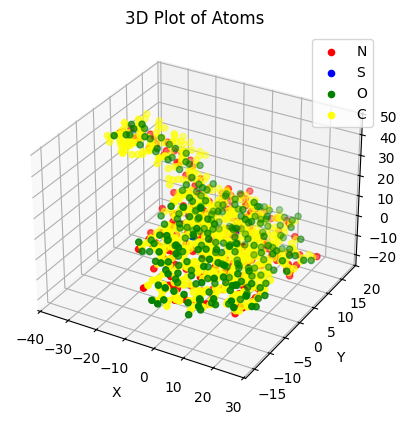

In [8]:
# Create 3D scatter plot
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot each atom type with a different color
unique_atoms = list(set(atom_type))
colors = ["red", "blue", "green", "yellow"]

for i, atom in enumerate(unique_atoms):
    mask = [a == atom for a in atom_type]
    ax.scatter(
        [x[j] for j in range(len(x)) if mask[j]],
        [y[j] for j in range(len(y)) if mask[j]],
        [z[j] for j in range(len(z)) if mask[j]],
        c=colors[i % len(colors)],
        label=atom,
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("3D Plot of Atoms")
ax.legend()
plt.show()

### 1.3) Splitting data

Equally important is that we all have the same datasplits to make sure our model comparisons are fair. Standard the dataset will load in the splits if they are present in the columns:

In [12]:
from pg2_dataset.backends.records import RecordsDataset
from pg2_dataset.backends.combined import CombinedDataset

dataset = CombinedDataset(
    toml_file="../example_data/dataset_split.toml",
    include_records=True,
    include_structure=True,
)

In [13]:
train = dataset.train
val = dataset.valid
test = dataset.test

print(f"The length of the training dataset is: {len(train.data_frame())}")
print(f"The length of the validation dataset is: {len(val.data_frame())}")
print(f"The length of the testing dataset is: {len(test.data_frame())}")

The length of the training dataset is: 533
The length of the validation dataset is: 193
The length of the testing dataset is: 196


**TODO:** We still need to add in kfold splitting. Current support is for a training/validation/test split

We wanted to add support for testing different splits:

In [27]:
from pg2_dataset.splits.random_split_strategy import RandomSplitStrategy

dataset.add_split(strategy=RandomSplitStrategy, train_ratio=0.2, valid_ratio=0.15)
train = dataset.train
val = dataset.valid
test = dataset.test


print(f"The length of the training dataset is: {len(train.data_frame())}")
print(f"The length of the validation dataset is: {len(val.data_frame())}")
print(f"The length of the testing dataset is: {len(test.data_frame())}")

The length of the training dataset is: 184
The length of the validation dataset is: 139
The length of the testing dataset is: 599


In [20]:
x_coordinates_of_the_train_structure = train.structure.atom_site.cartn_x

### 1.4) The introduction of engineering rounds

In [5]:
from pg2_dataset.backends.combined import CombinedDataset
from pg2_dataset.splits.random_split_strategy import RandomSplitStrategy

dataset = CombinedDataset(
    toml_file="../example_data/dataset_comb.toml",
    include_records=True,
    include_structure=True,
)

for enum, round_ds in enumerate(dataset.iter_by_rounds()):
    print(f"Round {enum + 1} contains {len(round_ds.data_frame())} records")
    print(f"Lets create the splits for round {enum + 1}")
    round_ds.add_split(strategy=RandomSplitStrategy, train_ratio=0.5, valid_ratio=0.25)

    print(
        f"The length of the training dataset for round {enum + 1} is: {len(round_ds.train.data_frame())}"
    )
    print(
        f"The length of the validation dataset for round {enum + 1} is: {len(round_ds.valid.data_frame())}"
    )
    print(
        f"The length of the testing dataset for round {enum + 1} is: {len(round_ds.test.data_frame())}"
    )

Round 1 contains 292 records
Lets create the splits for round 1
The length of the training dataset for round 1 is: 146
The length of the validation dataset for round 1 is: 73
The length of the testing dataset for round 1 is: 73
Round 2 contains 317 records
Lets create the splits for round 2
The length of the training dataset for round 2 is: 158
The length of the validation dataset for round 2 is: 80
The length of the testing dataset for round 2 is: 79
Round 3 contains 313 records
Lets create the splits for round 3
The length of the training dataset for round 3 is: 156
The length of the validation dataset for round 3 is: 79
The length of the testing dataset for round 3 is: 78
